# Digging Deeper: The Statistics

Charts are great, but are the differences we see actually "real" or just luck? In this notebook, we use math to prove our theories about Superhosts and room types.

## Setting the Stage

We'll load up our clean data and get our statistical tools ready. We also need to make sure our categories are ready for the regression models.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load the cleaned dataset
file_path = "../data/processed/cleaned_airbnb.csv"
df = pd.read_csv(file_path)

# Ensure numeric types for statistical tests
df["host_is_superhost"] = df["host_is_superhost"].map({"t": 1, "f": 0, 1: 1, 0: 0, 1.0: 1, 0.0: 0}).fillna(0)
df["instant_bookable"] = df["instant_bookable"].map({"t": 1, "f": 0, 1: 1, 0: 0, 1.0: 1, 0.0: 0}).fillna(0)
if df["price"].dtype == "object":
    df["price"] = df["price"].astype(str).str.replace(r"[\$,]", "", regex=True).astype(float)

print(f"Dataset Loaded: {df.shape[0]} listings, {df.shape[1]} columns")
df.head()

Dataset Loaded: 42904 listings, 36 columns


,review_scores_accuracy,host_acceptance_rate,availability_90,neighbourhood_cleansed,availability_60,bedrooms,review_scores_cleanliness,host_response_time,reviews_per_month,amenities,...,host_since,number_of_reviews,review_scores_location,price,review_scores_communication,number_of_reviews_ltm,review_scores_value,availability_30,beds,availability_365
0,3.44,100.0,46.0,THIRD WARD,16.0,2.0,3.56,Unknown,0.06,"[""Smoke alarm"", ""Kitchen"", ""Air conditioning"",...",...,Unknown,9.0,3.22,147.0,4.56,0.0,3.67,0.0,2.0,321.0
1,4.88,100.0,26.0,SIXTH WARD,0.0,1.0,4.87,Unknown,2.26,"[""Smoke alarm"", ""Kitchen"", ""Dishwasher"", ""Wifi...",...,Unknown,317.0,4.82,147.0,4.81,10.0,4.78,0.0,1.0,301.0
2,4.61,100.0,35.0,SECOND WARD,31.0,0.0,4.45,Unknown,2.96,"[""Smoke alarm"", ""Kitchen"", ""Wifi"", ""Shower gel...",...,Unknown,389.0,4.76,147.0,4.86,20.0,4.63,18.0,2.0,35.0
3,4.90,100.0,71.0,THIRTEENTH WARD,45.0,3.0,4.87,Unknown,0.66,"[""Smoke alarm"", ""Kitchen"", ""Gas stove"", ""Wifi""...",...,Unknown,0.0,4.83,147.0,4.96,0.0,4.78,20.0,3.0,324.0
4,4.83,100.0,73.0,SIXTH WARD,43.0,1.0,4.71,Unknown,2.55,"[""Smoke alarm"", ""Kitchen"", ""Dishwasher"", ""Wifi...",...,Unknown,332.0,4.80,147.0,4.70,1.0,4.72,13.0,1.0,348.0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42904 entries, 0 to 42903
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   review_scores_accuracy       42904 non-null  float64
 1   host_acceptance_rate         42904 non-null  float64
 2   availability_90              42904 non-null  float64
 3   neighbourhood_cleansed       42904 non-null  str    
 4   availability_60              42904 non-null  float64
 5   bedrooms                     42904 non-null  float64
 6   review_scores_cleanliness    42904 non-null  float64
 7   host_response_time           42904 non-null  str    
 8   reviews_per_month            42904 non-null  float64
 9   amenities                    42904 non-null  str    
 10  host_listings_count          42904 non-null  float64
 11  longitude                    42904 non-null  float64
 12  room_type                    42904 non-null  str    
 13  bathrooms                  

## 2. Descriptive Statistics — Mean, Median, Mode

In [21]:
# Select key numeric columns for descriptive analysis
numeric_cols = ['price', 'review_scores_rating', 'accommodates', 'bedrooms',
                'beds', 'bathrooms', 'availability_365', 'number_of_reviews',
                'reviews_per_month', 'estimated_revenue_l365d']

desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc['mode']   = df[numeric_cols].mode().iloc[0]
desc['skew']   = df[numeric_cols].skew()

print('=== Descriptive Statistics ===')
desc[['mean', 'median', 'mode', 'std', 'min', 'max', 'skew']]

=== Descriptive Statistics ===


,mean,median,mode,std,min,max,skew
price,653.401594,147.00,147.00,11655.630375,9.00,1000000.00,80.117151
review_scores_rating,4.787076,4.87,5.00,0.337833,0.00,5.00,-5.477981
accommodates,3.453011,3.00,2.00,2.119813,1.00,16.00,2.570231
bedrooms,1.488113,1.00,1.00,1.254672,0.00,50.00,11.522155
beds,2.029578,2.00,2.00,1.568543,0.00,50.00,6.668915
bathrooms,1.231855,1.00,1.00,0.680369,0.00,22.00,6.246854
availability_365,195.302886,234.00,0.00,139.870613,0.00,365.00,-0.247240
number_of_reviews,52.860969,13.00,0.00,109.401968,0.00,5097.00,7.606988
reviews_per_month,1.241365,0.66,0.66,1.791474,0.01,99.42,10.342319
estimated_revenue_l365d,27806.362460,4620.00,4620.00,102992.667319,0.00,5571432.00,14.916666


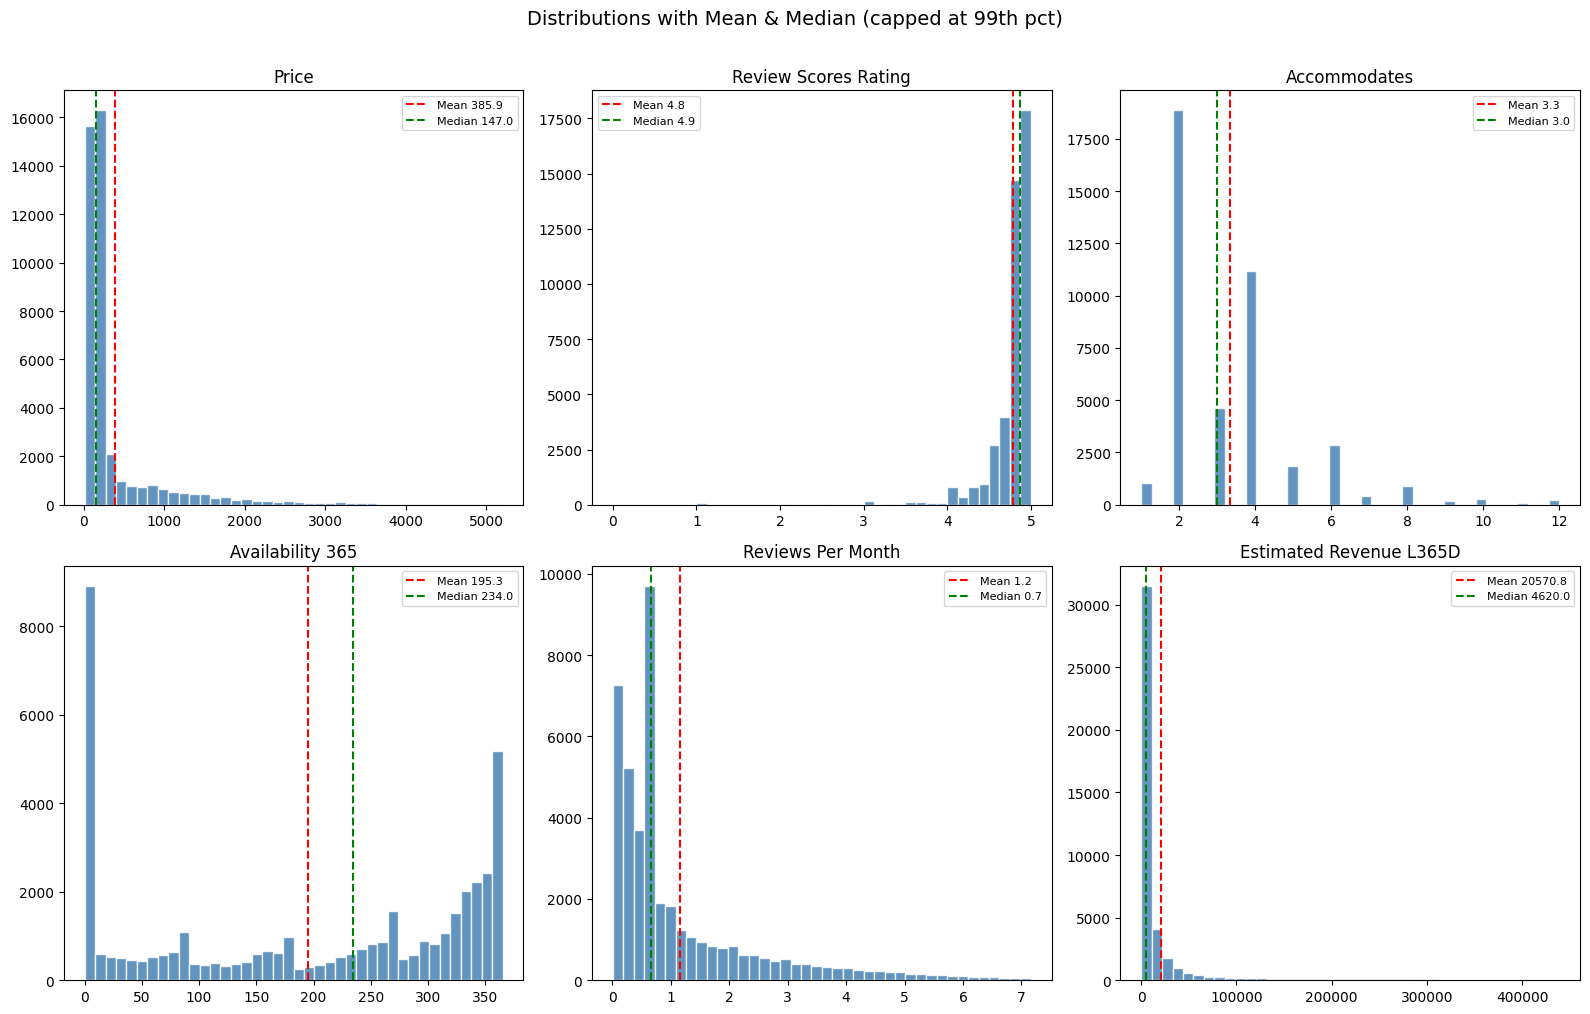

In [22]:
# Distribution plots for key variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_cols = ['price', 'review_scores_rating', 'accommodates',
             'availability_365', 'reviews_per_month', 'estimated_revenue_l365d']

for ax, col in zip(axes.flatten(), plot_cols):
    data = df[col].dropna()
    # Cap outliers at 99th percentile for readability
    cap = data.quantile(0.99)
    data = data[data <= cap]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color='green',  linestyle='--', linewidth=1.5, label=f'Median {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.suptitle('Distributions with Mean & Median (capped at 99th pct)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# Mode for categorical columns
cat_cols = ['room_type', 'property_type', 'neighbourhood_cleansed']
print('=== Mode for Categorical Columns ===')
for col in cat_cols:
    mode_val = df[col].mode()[0]
    freq     = df[col].value_counts().iloc[0]
    pct      = freq / len(df) * 100
    print(f'{col:35s}: {mode_val!r:<30} (n={freq}, {pct:.1f}%)')

=== Mode for Categorical Columns ===
room_type                          : 'Entire home/apt'              (n=34261, 79.9%)
property_type                      : 'Entire rental unit'           (n=19254, 44.9%)
neighbourhood_cleansed             : 'ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ'       (n=3253, 7.6%)


## 3. Hypothesis Testing

### 3a. Independent Samples t-test
**H₀:** Superhost listings and non-superhost listings have the same average price.  
**H₁:** They differ.

--- Independent t-test: Price ~ Superhost Status ---
Superhost     — Mean: $463.31,     n=14058
Non-Superhost — Mean: $746.04, n=28846
t-statistic : -3.3561
p-value     : 0.0008

✅ Reject H₀ — Significant price difference between superhost and non-superhost (α=0.05)


/var/folders/bx/pntfgnxn5573lnr105n2gckc0000gn/T/ipykernel_78889/1742097600.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Superhost', y='price', palette='Set2', ax=ax)


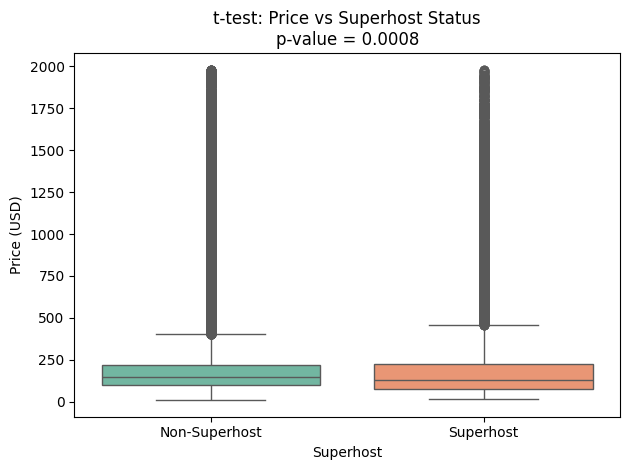

In [24]:
superhost     = df[df['host_is_superhost'] == 1]['price'].dropna()
non_superhost = df[df['host_is_superhost'] == 0]['price'].dropna()

t_stat, p_val = stats.ttest_ind(superhost, non_superhost, equal_var=False)  # Welch's t-test

print('--- Independent t-test: Price ~ Superhost Status ---')
print(f'Superhost     — Mean: ${superhost.mean():.2f},     n={len(superhost)}')
print(f'Non-Superhost — Mean: ${non_superhost.mean():.2f}, n={len(non_superhost)}')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.4f}')
print()
if p_val < 0.05:
    print('✅ Reject H₀ — Significant price difference between superhost and non-superhost (α=0.05)')
else:
    print('❌ Fail to reject H₀ — No significant price difference at α=0.05')

# Box plot
fig, ax = plt.subplots()
price_cap = df['price'].quantile(0.95)
plot_df = df[df['price'] <= price_cap].copy()
plot_df['Superhost'] = plot_df['host_is_superhost'].map({1: 'Superhost', 0: 'Non-Superhost'})
sns.boxplot(data=plot_df, x='Superhost', y='price', palette='Set2', ax=ax)
ax.set_title(f't-test: Price vs Superhost Status\np-value = {p_val:.4f}')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

### 3b. One-Way ANOVA
**H₀:** Average price is the same across all room types.  
**H₁:** At least one room type has a different average price.

--- One-Way ANOVA: Price ~ Room Type ---
                    mean  median  count
room_type                              
Entire home/apt   602.81   147.0  34261
Hotel room       1318.38   160.0    519
Private room      836.00   147.0   7955
Shared room       273.89   200.0    167
Unknown           147.00   147.0      2

F-statistic : 1.1170
p-value     : 3.4638e-01

❌ Fail to reject H₀


/var/folders/bx/pntfgnxn5573lnr105n2gckc0000gn/T/ipykernel_78889/4259690958.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['price'] <= price_cap], x='room_type', y='price', palette='pastel', ax=ax)


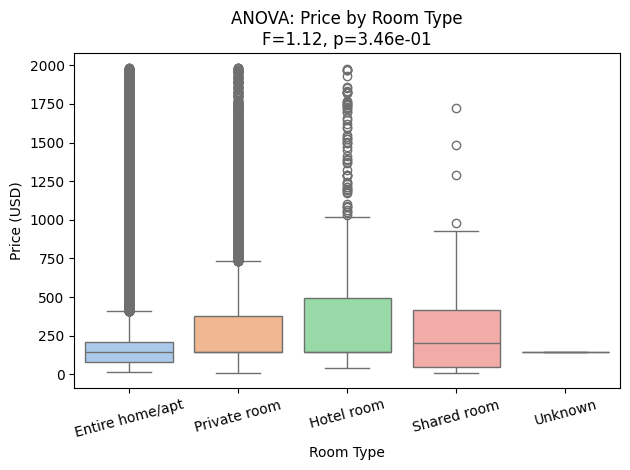

In [25]:
room_groups = [grp['price'].dropna().values
               for _, grp in df.groupby('room_type')]

f_stat, p_val_anova = stats.f_oneway(*room_groups)

print('--- One-Way ANOVA: Price ~ Room Type ---')
print(df.groupby('room_type')['price'].agg(['mean', 'median', 'count']).round(2))
print()
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val_anova:.4e}')
print()
if p_val_anova < 0.05:
    print('✅ Reject H₀ — Significant price difference across room types (α=0.05)')
else:
    print('❌ Fail to reject H₀')

fig, ax = plt.subplots()
sns.boxplot(data=df[df['price'] <= price_cap], x='room_type', y='price', palette='pastel', ax=ax)
ax.set_title(f'ANOVA: Price by Room Type\nF={f_stat:.2f}, p={p_val_anova:.2e}')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 3c. Chi-Square Test of Independence
**H₀:** Room type and instant bookable status are independent.  
**H₁:** They are associated.

Contingency Table:
                 Not Instant  Instant Bookable
room_type                                     
Entire home/apt        19198             15063
Hotel room               153               366
Private room            4824              3131
Shared room               71                96
Unknown                    2                 0

Chi-Square  : 227.5427
p-value     : 4.4624e-48
Degrees of freedom: 4

✅ Reject H₀ — Room type and instant bookable are significantly associated


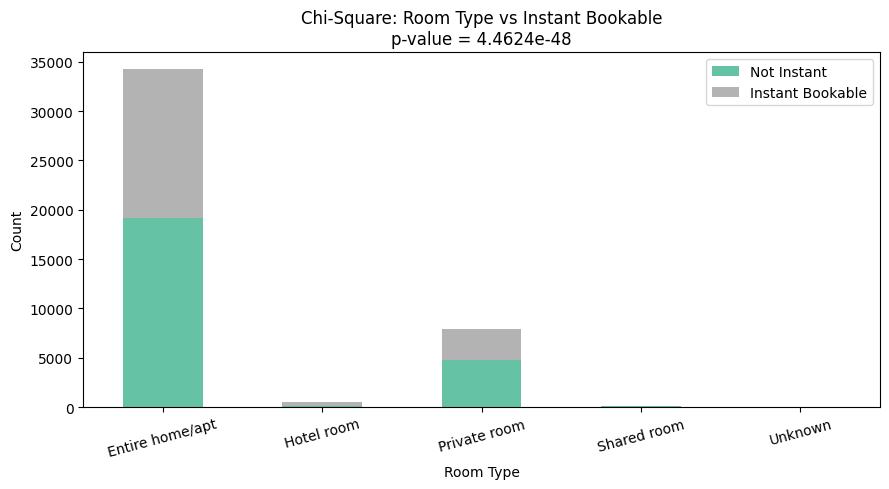

In [26]:
contingency = pd.crosstab(df['room_type'], df['instant_bookable'])
contingency.columns = ['Not Instant', 'Instant Bookable']
print('Contingency Table:')
print(contingency)
print()

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-Square  : {chi2:.4f}')
print(f'p-value     : {p_chi2:.4e}')
print(f'Degrees of freedom: {dof}')
print()
if p_chi2 < 0.05:
    print('✅ Reject H₀ — Room type and instant bookable are significantly associated')
else:
    print('❌ Fail to reject H₀')

contingency.plot(kind='bar', stacked=True, colormap='Set2', figsize=(9, 5))
plt.title(f'Chi-Square: Room Type vs Instant Bookable\np-value = {p_chi2:.4e}')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## What's connected to what?

We want to see which features (like bedrooms or location) have the strongest link to the final price. This helps us understand what guests actually value.

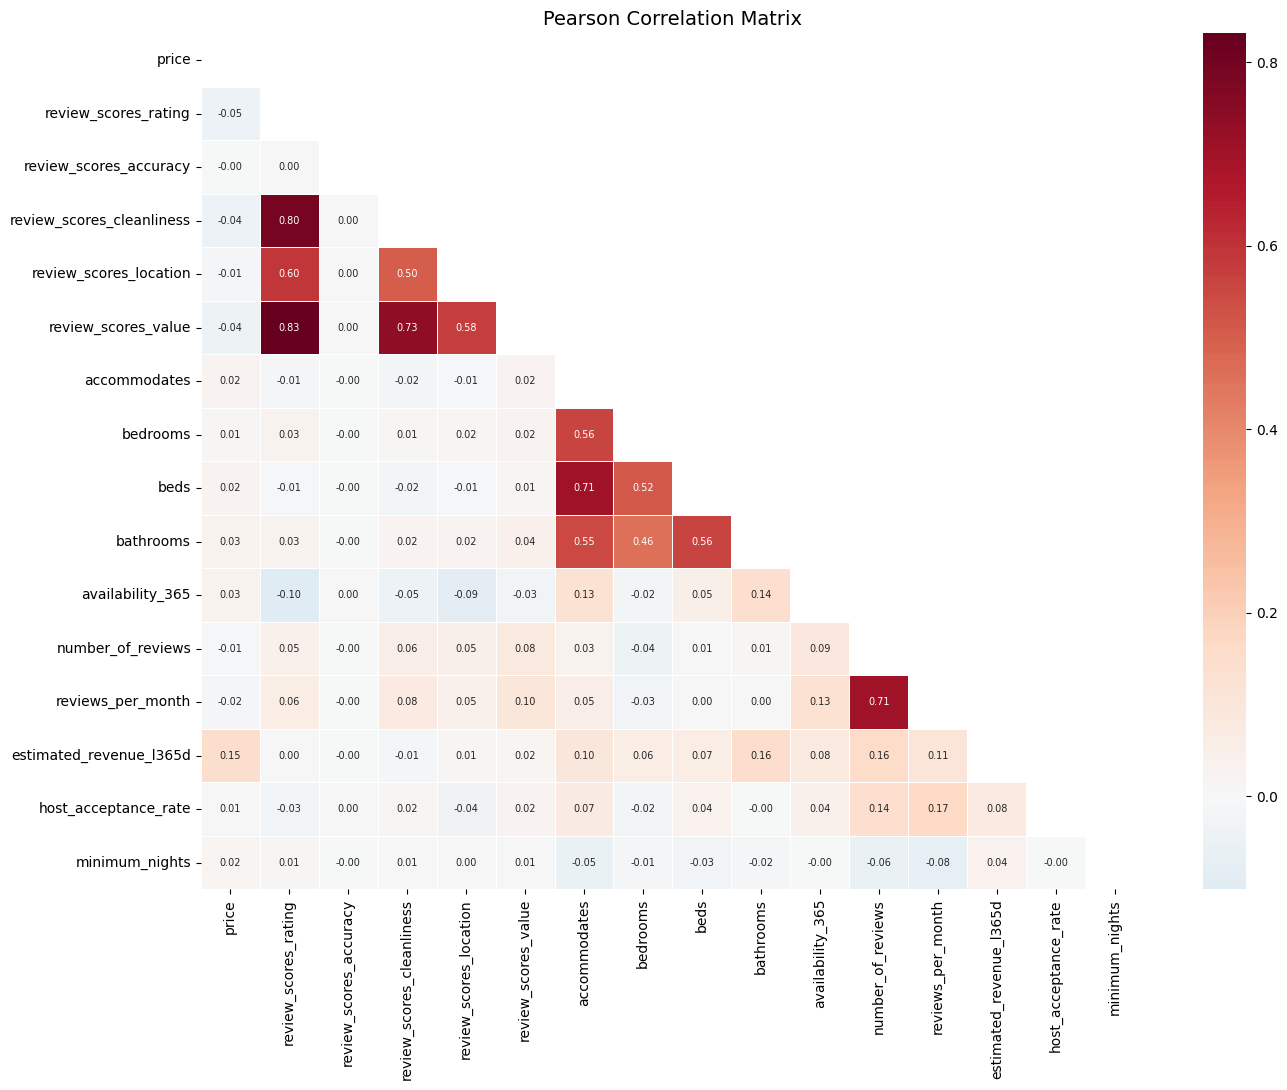

In [27]:
corr_cols = ['price', 'review_scores_rating', 'review_scores_accuracy',
             'review_scores_cleanliness', 'review_scores_location',
             'review_scores_value', 'accommodates', 'bedrooms', 'beds',
             'bathrooms', 'availability_365', 'number_of_reviews',
             'reviews_per_month', 'estimated_revenue_l365d',
             'host_acceptance_rate', 'minimum_nights']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

=== Top Correlations with Price ===
estimated_revenue_l365d      0.1465
review_scores_rating        -0.0454
review_scores_cleanliness   -0.0431
review_scores_value         -0.0374
bathrooms                    0.0276
availability_365             0.0271
accommodates                 0.0226
beds                         0.0193
minimum_nights               0.0159
reviews_per_month           -0.0156
bedrooms                     0.0129
review_scores_location      -0.0107
number_of_reviews           -0.0071
host_acceptance_rate         0.0051
review_scores_accuracy      -0.0002


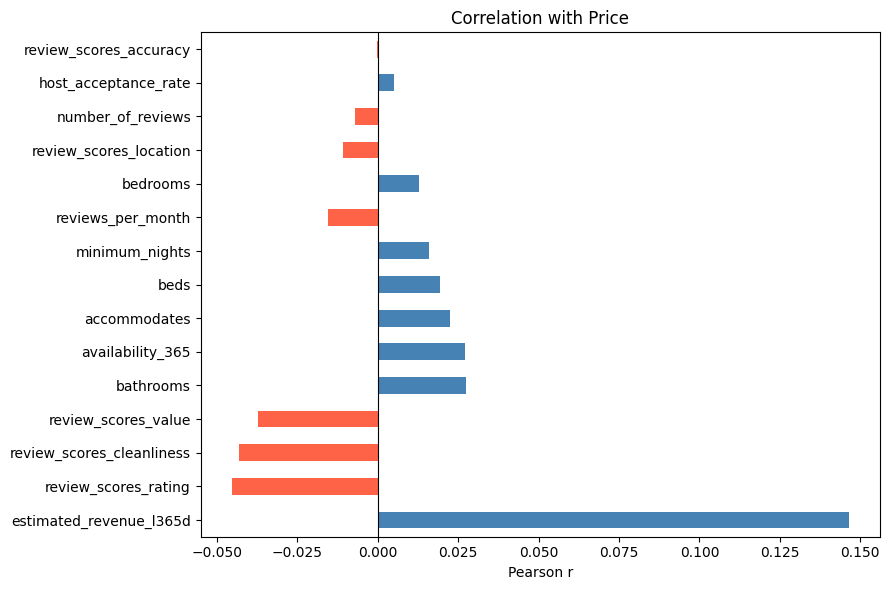

In [28]:
# Top correlations with price
price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)
print('=== Top Correlations with Price ===')
print(price_corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in price_corr]
price_corr.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Price')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

In [29]:
# Spearman correlation (robust to outliers / non-normal distributions)
spearman_corr = df[corr_cols].corr(method='spearman')
spearman_price = spearman_corr['price'].drop('price').sort_values(key=abs, ascending=False)
print('=== Spearman Correlation with Price ===')
print(spearman_price.round(4).to_string())

=== Spearman Correlation with Price ===
reviews_per_month           -0.2451
bathrooms                    0.2347
estimated_revenue_l365d      0.2097
bedrooms                     0.1441
minimum_nights               0.1281
host_acceptance_rate        -0.1084
number_of_reviews           -0.0886
beds                         0.0601
review_scores_location       0.0572
review_scores_value         -0.0541
accommodates                 0.0367
review_scores_rating         0.0360
availability_365             0.0229
review_scores_cleanliness   -0.0143
review_scores_accuracy       0.0125


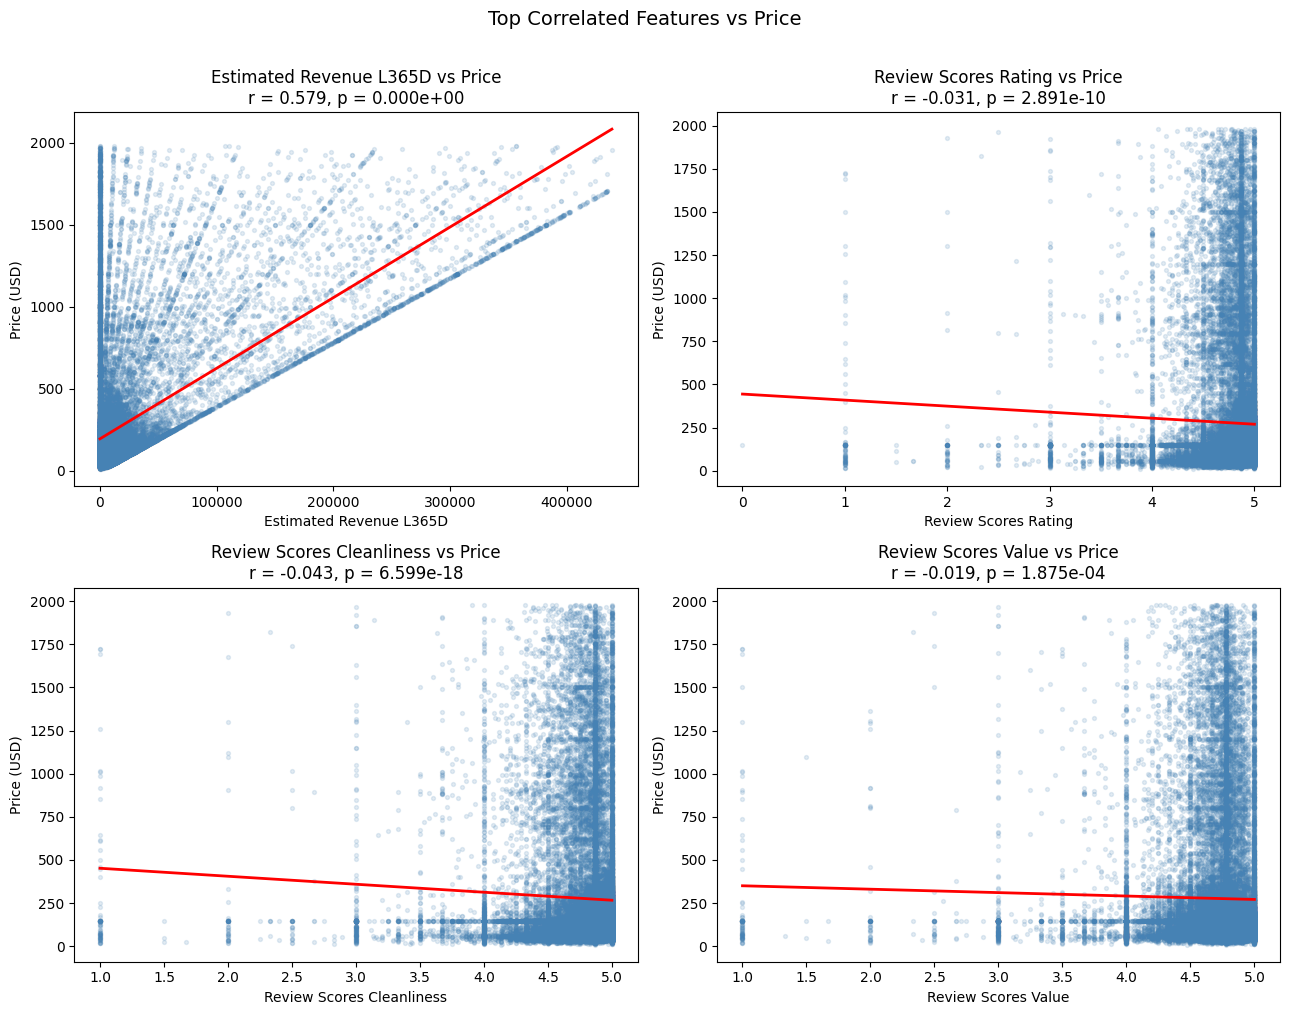

In [30]:
# Scatter plots for top 4 correlated numeric features vs price
top4 = price_corr.abs().nlargest(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, col in zip(axes.flatten(), top4):
    sub = df[[col, 'price']].dropna()
    cap_p = sub['price'].quantile(0.95)
    cap_c = sub[col].quantile(0.99)
    sub = sub[(sub['price'] <= cap_p) & (sub[col] <= cap_c)]
    r, p = stats.pearsonr(sub[col], sub['price'])
    ax.scatter(sub[col], sub['price'], alpha=0.15, s=8, color='steelblue')
    m, b = np.polyfit(sub[col], sub['price'], 1)
    x_line = np.linspace(sub[col].min(), sub[col].max(), 200)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Price (USD)')
    ax.set_title(f'{col.replace("_", " ").title()} vs Price\nr = {r:.3f}, p = {p:.3e}')

plt.suptitle('Top Correlated Features vs Price', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Regression Analysis

### 5a. Simple Linear Regression — Price ~ Accommodates

=== Simple Linear Regression: Price ~ Accommodates ===
Intercept  : 297.1095
Slope      : -5.9043  (price increases $-5.90 per additional guest)
R²         : 0.0010
p-value    : 1.0473e-10
Std Error  : 0.9138


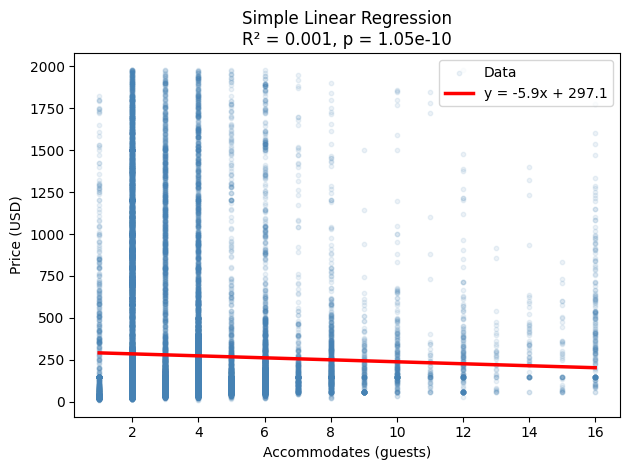

In [31]:
from scipy.stats import linregress

slr_data = df[['accommodates', 'price']].dropna()
slr_data = slr_data[slr_data['price'] <= slr_data['price'].quantile(0.95)]

X_slr = slr_data['accommodates'].values
y_slr = slr_data['price'].values

slope, intercept, r_value, p_value, std_err = linregress(X_slr, y_slr)

print('=== Simple Linear Regression: Price ~ Accommodates ===')
print(f'Intercept  : {intercept:.4f}')
print(f'Slope      : {slope:.4f}  (price increases ${slope:.2f} per additional guest)')
print(f'R²         : {r_value**2:.4f}')
print(f'p-value    : {p_value:.4e}')
print(f'Std Error  : {std_err:.4f}')

fig, ax = plt.subplots()
ax.scatter(X_slr, y_slr, alpha=0.1, s=10, color='steelblue', label='Data')
x_line = np.linspace(X_slr.min(), X_slr.max(), 200)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2.5, label=f'y = {slope:.1f}x + {intercept:.1f}')
ax.set_xlabel('Accommodates (guests)')
ax.set_ylabel('Price (USD)')
ax.set_title(f'Simple Linear Regression\nR² = {r_value**2:.3f}, p = {p_value:.2e}')
ax.legend()
plt.tight_layout()
plt.show()

### 5b. Multiple Linear Regression — Price ~ Multiple Features

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

features = ['accommodates', 'bedrooms', 'beds', 'bathrooms',
            'availability_365', 'number_of_reviews', 'reviews_per_month',
            'host_acceptance_rate', 'minimum_nights',
            'review_scores_rating', 'host_is_superhost', 'instant_bookable']

mlr_df = df[features + ['price']].dropna()
mlr_df = mlr_df[mlr_df['price'] <= mlr_df['price'].quantile(0.95)]

X = mlr_df[features]
y = mlr_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test.values - y_pred))

print('=== Multiple Linear Regression: Price ~ Features ===')
print(f'R²   (test): {r2:.4f}')
print(f'RMSE (test): {rmse:.4f}')
print(f'MAE  (test): {mae:.4f}')
print()
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

=== Multiple Linear Regression: Price ~ Features ===
R²   (test): 0.0779
RMSE (test): 356.1470
MAE  (test): 226.9214

             Feature  Coefficient
   reviews_per_month   -74.553807
    availability_365    68.713993
           bathrooms    61.477598
   number_of_reviews    38.055128
        accommodates   -38.046814
      minimum_nights    26.663654
    instant_bookable   -18.783529
review_scores_rating    -8.315960
                beds    -7.216597
   host_is_superhost     2.371186
            bedrooms    -0.711832
host_acceptance_rate     0.146154


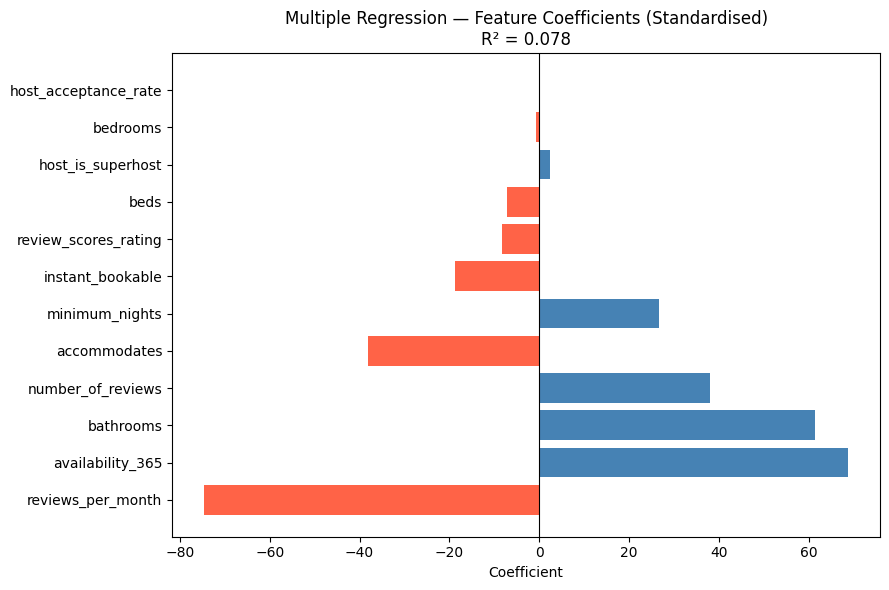

In [33]:
# Coefficient plot
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Multiple Regression — Feature Coefficients (Standardised)\nR² = {r2:.3f}')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

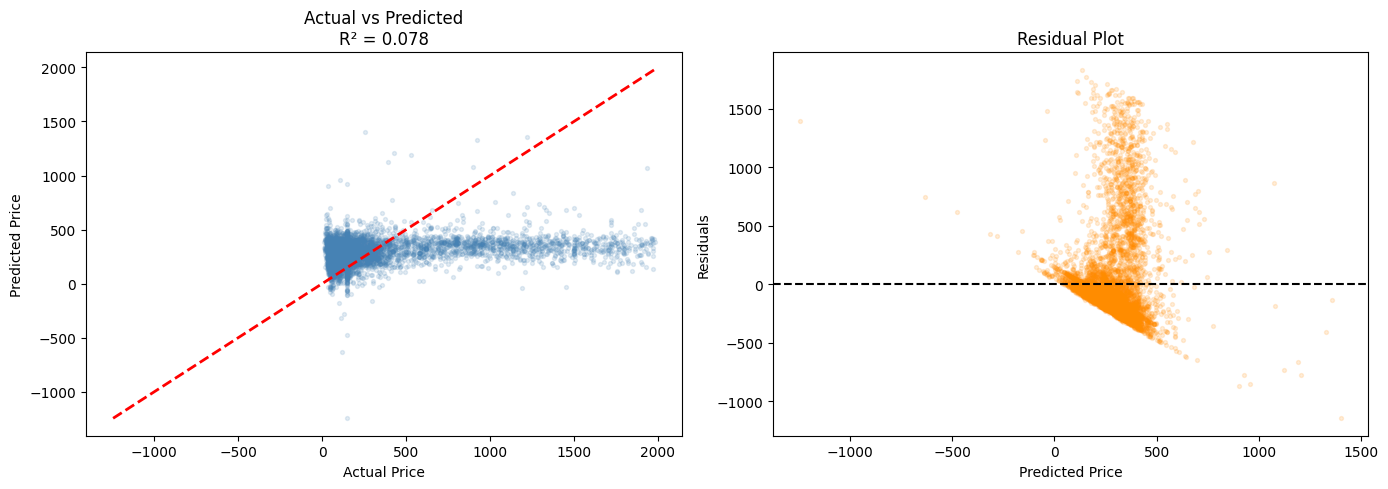

In [34]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.15, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.3f}')

residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.15, s=8, color='darkorange')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

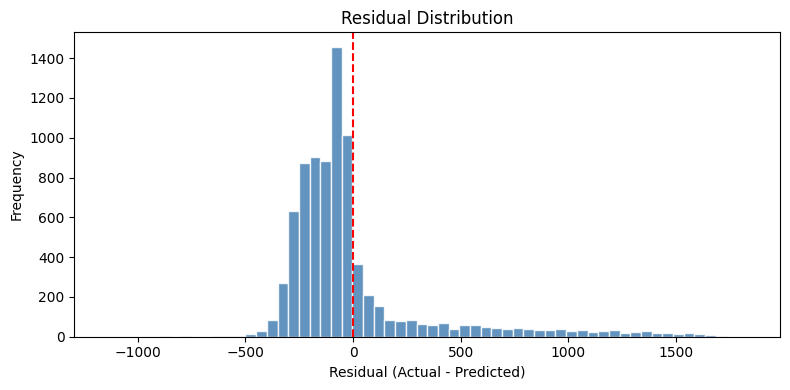

Shapiro-Wilk test on residuals (n=5000): stat=0.7110, p=9.6092e-69
Residuals are NOT normally distributed — consider log-transform of price or robust regression.


In [35]:
# Residual distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Shapiro-Wilk on a sample (full residuals too large)
sample_residuals = residuals[:5000]
stat, p_norm = stats.shapiro(sample_residuals)
print(f'Shapiro-Wilk test on residuals (n=5000): stat={stat:.4f}, p={p_norm:.4e}')
if p_norm < 0.05:
    print('Residuals are NOT normally distributed — consider log-transform of price or robust regression.')
else:
    print('Residuals appear normally distributed.')

---
## Summary Table

In [36]:
summary = pd.DataFrame([
    ['Mean Price',           f'${df["price"].mean():.2f}'],
    ['Median Price',         f'${df["price"].median():.2f}'],
    ['Mode Price',           f'${df["price"].mode()[0]:.2f}'],
    ['t-test p-value',       f'{p_val:.4f} — Superhost vs Non-Superhost'],
    ['ANOVA p-value',        f'{p_val_anova:.4e} — Price across Room Types'],
    ['Chi-Square p-value',   f'{p_chi2:.4e} — Room Type vs Instant Bookable'],
    ['Top Pearson Corr',     f'{price_corr.index[0]} (r={price_corr.iloc[0]:.3f})'],
    ['Simple LR R²',         f'{r_value**2:.4f} (Price ~ Accommodates)'],
    ['Multiple LR R²',       f'{r2:.4f}'],
    ['Multiple LR RMSE',     f'{rmse:.2f}'],
], columns=['Metric', 'Value'])

print(summary.to_string(index=False))

            Metric                                      Value
        Mean Price                                    $653.40
      Median Price                                    $147.00
        Mode Price                                    $147.00
    t-test p-value        0.0008 — Superhost vs Non-Superhost
     ANOVA p-value       3.4638e-01 — Price across Room Types
Chi-Square p-value 4.4624e-48 — Room Type vs Instant Bookable
  Top Pearson Corr          estimated_revenue_l365d (r=0.147)
      Simple LR R²              0.0010 (Price ~ Accommodates)
    Multiple LR R²                                     0.0779
  Multiple LR RMSE                                     356.15
